## [Embedding](https://docs.langchain.com/oss/python/integrations/text_embedding/index#embedding-models)

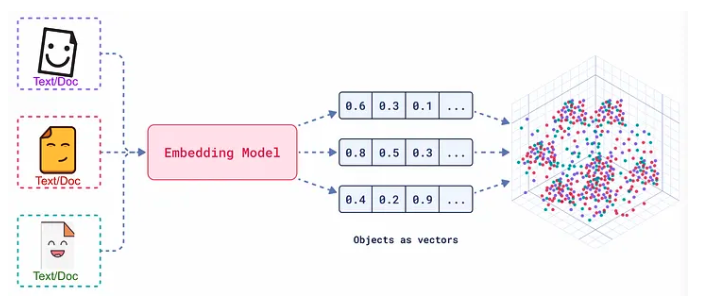

- 임베딩(Embedding)은 텍스트 데이터를 숫자로 이루어진 벡터로 변환하는 과정을 말합니다.
- 이러한 벡터 표현을 사용하면, 텍스트 데이터를 벡터 공간 내에서 수학적으로 다룰 수 있게 되며, 이를 통해 텍스트 간의 유사성을 계산하거나, 텍스트 데이터를 기반으로 하는 다양한 머신러닝 및 자연어 처리 작업을 수행할 수 있습니다.
- 임베딩 과정은 텍스트의 의미적인 정보를 보존하도록 설계되어 있어, 벡터 공간에서 가까이 위치한 텍스트 조각들은 의미적으로도 유사한 것으로 간주됩니다.

임베딩의 주요 활용 사례:
- `의미 검색(Semantic Search)`: 벡터 표현을 활용하여 의미적으로 유사한 텍스트를 검색하는 과정으로, 사용자가 입력한 쿼리에 대해 가장 관련성 높은 문서나 정보를 찾아내는 데 사용됩니다.
- `문서 분류(Document Classification)`: 임베딩된 텍스트 벡터를 사용하여 문서를 특정 카테고리나 주제에 할당하는 분류 작업에 사용됩니다.
- `텍스트 유사도 계산(Text Similarity Calculation)`: 두 텍스트 벡터 사이의 거리를 계산하여, 텍스트 간의 유사성 정도를 정량적으로 평가합니다.

임베딩 모델 제공자:
- `OpenAI`: GPT와 같은 언어 모델을 통해 텍스트의 임베딩 벡터를 생성할 수 있는 API를 제공합니다.
- `Hugging Face`: Transformers 라이브러리를 통해 다양한 오픈소스 임베딩 모델을 제공합니다.
- `Google`: Gemini, Gemma 등 언어 모델에 적용되는 임베딩 모델을 제공합니다.

임베딩 메소드:
- `embed_documents`: 이 메소드는 문서 객체의 집합을 입력으로 받아, 각 문서를 벡터 공간에 임베딩합니다. 주로 대량의 텍스트 데이터를 배치 단위로 처리할 때 사용됩니다.
- `embed_query`: 이 메소드는 단일 텍스트 쿼리를 입력으로 받아, 쿼리를 벡터 공간에 임베딩합니다. 주로 사용자의 검색 쿼리를 임베딩하여, 문서 집합 내에서 해당 쿼리와 유사한 내용을 찾아내는 데 사용됩니다.

임베딩은 텍스트 데이터를 머신러닝 모델이 이해할 수 있는 형태로 변환하는 핵심 과정입니다. 다양한 자연어 처리 작업의 기반이 되는 중요한 작업입니다.

# Setup

## API Key 등록 

- [OpenAI Key 발급](https://platform.openai.com/api-keys)

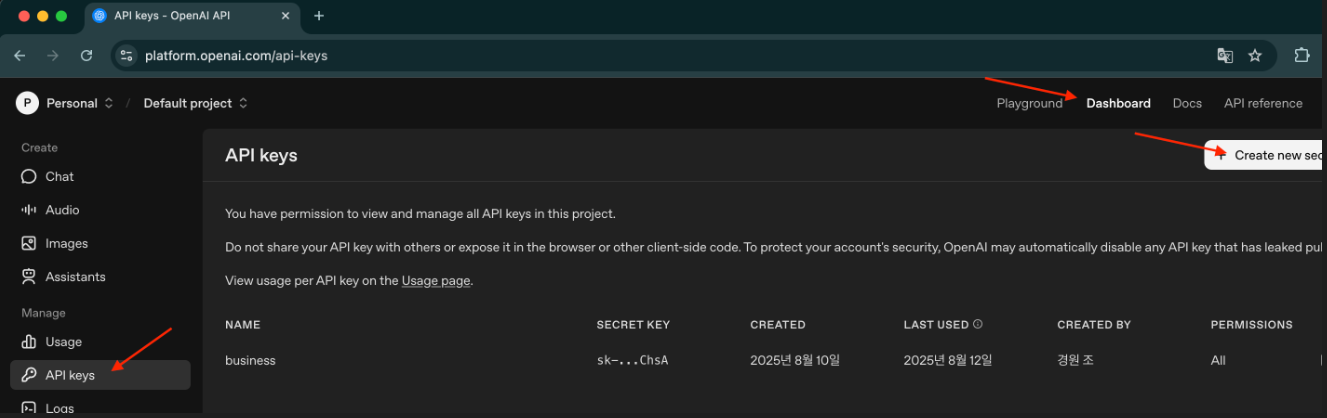

In [1]:
from dotenv import load_dotenv 

load_dotenv()


True

# Embedding 테스트용 함수

In [2]:
from sklearn.metrics.pairwise import cosine_similarity

def similarity(a, b):
    return cosine_similarity([a], [b])[0][0]


In [3]:
def test_embedding(embedding_model):
    sentences = [
        '안녕하세요!',
        '어! 오랜만이에요',
        '이름이 어떻게 되세요?',
        '날씨가 추워요',
        'Hello LLM!'
    ]
    query = '첫인사를 하고 이름을 물어봤나요?'
    embeddings = embedding_model.embed_documents(sentences)
    embedded_query = embedding_model.embed_query(query)

    for i, embedding in enumerate(embeddings):
        print(
            f"""
            [유사도 {similarity(embedding, embedded_query):.4f}] {query} \t <=====> \t {sentences[i]}
            """
        )

# [OpenAI Embeddings](https://python.langchain.com/docs/integrations/text_embedding/openai/)
- `OpenAIEmbeddings` 클래스는 OpenAI의 API를 활용하여, 각 문서를 대응하는 임베딩 벡터로 변환합니다.
- `langchain_openai` 라이브러리에서 `OpenAIEmbeddings` 클래스를 직접 임포트합니다.

## [OpenAI Embedding Models](https://platform.openai.com/docs/guides/embeddings/embedding-models#embedding-models)

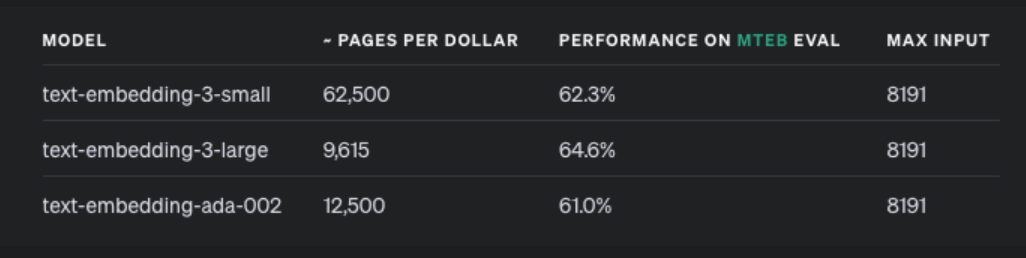

In [4]:
from langchain_openai import OpenAIEmbeddings

embeddings_model = OpenAIEmbeddings(model="text-embedding-3-small")

- Embed single text:

In [5]:
input_text = "The meaning of life is 42"
vector = embeddings_model.embed_query(input_text)

print(f"변환된 벡터의 크기: {len(vector)}")

변환된 벡터의 크기: 1536


In [6]:
# 변환된 벡터 데이터의 일부 확인 
vector[:3]

[0.020976193249225616, -0.02854049764573574, 0.003906212281435728]

- Embed multiple texts:

In [7]:
vectors = embeddings_model.embed_documents(["hello", "goodbye"])
# Showing only the first 3 coordinates
print(f"벡터로 변환된 데이터의 수: {len(vectors)}")
print(f"첫번째 벡터의 데이터 일부 확인: {vectors[0][:3]}")

벡터로 변환된 데이터의 수: 2
첫번째 벡터의 데이터 일부 확인: [0.016751619055867195, -0.055799614638090134, 0.005647437181323767]


## test_embedding 테스트 

In [8]:
test_embedding(embeddings_model)


            [유사도 0.1777] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 안녕하세요!
            

            [유사도 0.1748] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 어! 오랜만이에요
            

            [유사도 0.4413] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 이름이 어떻게 되세요?
            

            [유사도 0.0452] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 날씨가 추워요
            

            [유사도 0.1411] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 Hello LLM!
            


## 차원(dimensions) 조정
- dimensions=1024를 전달함으로써 임베딩의 크기를 1024로 줄일 수 있습니다.

In [9]:
# OpenAI의 "text-embedding-3-small" 모델을 사용하여 1024차원의 임베딩을 생성하는 객체를 초기화합니다.
embeddings_1024 = OpenAIEmbeddings(
    model="text-embedding-3-small", dimensions=1024)


In [10]:
# 주어진 텍스트를 임베딩하고 첫 번째 임베딩 벡터의 길이를 반환합니다.
input_text = "The meaning of life is 42"
len(embeddings_1024.embed_documents([input_text])[0])


1024

- test_embedding

In [11]:
test_embedding(embeddings_1024)


            [유사도 0.2008] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 안녕하세요!
            

            [유사도 0.2064] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 어! 오랜만이에요
            

            [유사도 0.4519] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 이름이 어떻게 되세요?
            

            [유사도 0.0749] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 날씨가 추워요
            

            [유사도 0.1633] 첫인사를 하고 이름을 물어봤나요? 	 <=====> 	 Hello LLM!
            
